In [1]:
import warnings
warnings.filterwarnings('ignore')

from facenet_pytorch import MTCNN, InceptionResnetV1
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import argparse
from cloaker import Cloaker
from cloak_functions import pgd_cloak, sgd_cloak, afog_cloak, pgd_cloak_multi, minmax_cloak
from loss_functions import fawkes_loss, triplet_loss, dssim_loss, lpips_loss, untarget_loss
from dist_functions import cosine_dist, l2_dist
from utils import preprocess_tanh, reverse_tanh, preprocess_divide, reverse_divide
#from insightface.recognition.arcface_torch.backbones import get_model
import matplotlib.pyplot as plt
import os
%matplotlib inline
%load_ext autoreload
%autoreload 2


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Configure all of the variables
dataset_path="../data/pubfig_small_flat"
extractor_path=None
batch_size=32
cropped_im_size = 112
target_pool_size = 100
num_cloaked_images = 100
num_dataset_images = 1.0
cloak_save_path = None
verbosity = "none"
extractor_type = "Facenet"
distance_function = "cosine"
norm_function = "divide"
cloak_function = "minmax_cloak"
multi_cloak_function = "pgd_cloak_multi"
cloak_loss = "triplet"
multi_cloak_loss = "triplet"
cloak_function_iters = 10
multi_cloak_function_iters = 10
cloak_function_step = 2.
cloak_function_max_pert = 16
multi_cloak_function_max_pert = 16
cloak_function_lr = 0.5
cloak_percep_loss = "dssim"
percep_loss_weight = 0.0
mode = "perturb"
makeup_mode = None
gen_save_path = "data/gen/notebook"

cloak_function_step = cloak_function_step / 255.
cloak_function_max_pert = cloak_function_max_pert / 255.
multi_cloak_function_max_pert = multi_cloak_function_max_pert / 255.

model_shorthands = {
        "ArcFaceR18":"r18",
        "ArcFaceR34":"r34",
        "ArcFaceR50":"r50",
        "ArcFaceR100":"r100",
        "CosFaceR18":"r18",
        "CosFaceR34":"r34",
        "CosFaceR50":"r50",
        "CosFaceR100":"r100",
        }

model_paths = {
        "ArcFaceR18":"model_checkpoints/arcface_r18_ms1mv3.pth",
        "ArcFaceR34":"model_checkpoints/arcface_r34_ms1mv3.pth",
        "ArcFaceR50":"model_checkpoints/arcface_r50_ms1mv3.pth",
        "ArcFaceR100":"model_checkpoints/arcface_r100_ms1mv3.pth",
        "CosFaceR18":"model_checkpoints/cosface_r18_glint360k.pth",
        "CosFaceR34":"model_checkpoints/cosface_r34_glint360k.pth",
        "CosFaceR50":"model_checkpoints/cosface_r50_glint360k.pth",
        "CosFaceR100":"model_checkpoints/cosface_r100_glint360k.pth",
        }

# Note: a function below adds CosFace and ArcFace models to this dictionary
extractors = {
        #"ArcFace":torch_arcface_insightface(device).to(device),
        "Facenet":InceptionResnetV1(pretrained='vggface2').to(device)
    }

cloak_funcs = {
        "pgd_cloak":pgd_cloak,
        "pgd_cloak_multi":pgd_cloak_multi,
        "minmax_cloak": minmax_cloak,
        "sgd_cloak":sgd_cloak,
        "afog_cloak":afog_cloak,
        "none":None
    }

cloak_losses = {
        "fawkes":fawkes_loss,
        "triplet":triplet_loss,
        "untarget":untarget_loss,
        "none":None
    }

distance_funcs = {
        "cosine":cosine_dist,
        "l2":l2_dist
    }

norm_funcs = {
        "tanh":preprocess_tanh,
        "divide":preprocess_divide
        }

reverse_norm_funcs = {
        "tanh":reverse_tanh,
        "divide":reverse_divide
        }

percep_losses = {
        "dssim": dssim_loss,
        "lpips": lpips_loss,
        "none": None
        }

# Handle loading in the weights of an insightface model (arcface or cosface)
def load_arcface_cosface_model(model):
    if_model = get_model(model_shorthands[model], fp16=False)
    if_model.load_state_dict(torch.load(model_paths[model], map_location=device))
    if_model.eval().to(device)
    extractors[model] = if_model

# Get the extractor, cloaking optimization function, loss function. If we're using ArcFace or CosFace, normalize accordingly
if "ArcFace" in extractor_type or "CosFace" in extractor_type:
    load_arcface_cosface_model(extractor_type)
    norm_function = preprocess_divide
    reverse_norm_function = reverse_divide

extractor = extractors[extractor_type]
cloak_function = cloak_funcs[cloak_function]
multi_cloak_function = cloak_funcs[multi_cloak_function]
loss_function = cloak_losses[cloak_loss]
multi_loss_function = cloak_losses[multi_cloak_loss]
distance_function = distance_funcs[distance_function]
norm = norm_funcs[norm_function]
reverse_norm = reverse_norm_funcs[norm_function]
percep_loss_function = percep_losses[cloak_percep_loss]


# Get MTCNN for crop and align
mtcnn = MTCNN(image_size=cropped_im_size, device=device).to(device)

print("Extracting with model:", extractor_type)

# Initialize cloaker
cloaker = Cloaker(
        dataset_path=dataset_path, 
        extractor=extractor, 
        cropper=mtcnn, 
        batch_size=batch_size, 
        cropped_im_size=cropped_im_size, 
        target_pool_size=target_pool_size, 
        num_dataset_images=num_dataset_images, 
        device=device, 
        verbosity=verbosity,
        distance_function=distance_function,
        cloak_function=cloak_function,
        multi_cloak_function = multi_cloak_function,
        cloak_loss=loss_function,
        multi_cloak_loss=multi_loss_function,
        cloak_function_iters=cloak_function_iters,
        multi_cloak_function_iters=multi_cloak_function_iters,
        cloak_function_step=cloak_function_step,
        cloak_function_max_pert=cloak_function_max_pert,
        multi_cloak_function_max_pert=multi_cloak_function_max_pert,
        cloak_function_lr=cloak_function_lr,
        loss_func_select=cloak_loss,
        multi_loss_func_select=multi_cloak_loss,
        norm_function = norm,
        reverse_norm_function = reverse_norm,
        percep_loss = percep_loss_function,
        percep_loss_weight = percep_loss_weight,
        mode=mode
        )

2025-09-04 15:32:59.906302: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-04 15:33:11.683468: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-04 15:33:12.969324: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-04 15:33:29.211782: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Co

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/hice1/zyahn3/.conda/envs/Face/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
Extracting with model: Facenet
Loading dataset with 500 images.
Cloaker is using device cuda


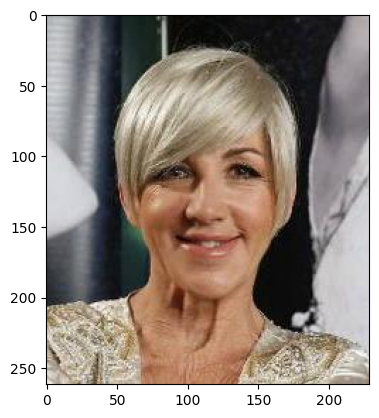

PGD expects cropped of size torch.Size([1, 3, 112, 112])
---- Min-Max Iter 0 -----


KeyError: 'device'

In [2]:
IMAGE_PATH = "../data/vggface_small_flat/n000454_008201.jpg"
SECOND_IMAGE_PATH = "../data/pubfig_small_flat/AngelinaJolie_21.jpg"

orig_im = cv2.imread(IMAGE_PATH)
orig_im = cv2.cvtColor(orig_im, cv2.COLOR_BGR2RGB)
plt.imshow(orig_im)
plt.show()

cloaked_im = cloaker.cloak_image(img_path=IMAGE_PATH, pool_size=100)
plt.imshow(cloaked_im)
plt.show()

diff = np.abs(orig_im - cloaked_im)
# print("diff min, max are:", np.min(diff), np.max(diff))
# diff = np.clip(diff, a_min=230, a_max=255) 
#plt.set_cmap('Grays')
plt.imshow(diff)
plt.show()

# plt.hist(diff.flatten(), bins=100)
# plt.show()

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"        # or a small number like 4
os.environ["OMP_WAIT_POLICY"] = "PASSIVE"  # optional, prevents spin-lock CPU usage
os.environ["ONNX_DISABLE_CPU_AFFINITY"] = "1"
os.environ["ORT_DISABLE_GPU"] = "1"

import onnxruntime as ort
ort.set_default_logger_severity(4)  # 0=verbose, 1=info, 2=warning, 3=error, 4=fatal


from arc2face.Arc2Face.arc2face import CLIPTextModelWrapper, project_face_embs
import torch
import cv2
import matplotlib.pyplot as plt
import sys
import os
import time
import gc
import numpy as np
%matplotlib inline
%load_ext autoreload
%autoreload 2

from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    DPMSolverMultistepScheduler,
)

# Arc2Face is built upon SD1.5
# The repo below can be used instead of the now deprecated 'runwayml/stable-diffusion-v1-5'
base_model = 'stable-diffusion-v1-5/stable-diffusion-v1-5'

encoder = CLIPTextModelWrapper.from_pretrained(
    "arc2face/encoder", torch_dtype=torch.float16
)

unet = UNet2DConditionModel.from_pretrained(
    "arc2face/Arc2Face", torch_dtype=torch.float16
)


pipeline = StableDiffusionPipeline.from_pretrained(
        base_model,
        text_encoder=encoder,
        unet=unet,
        torch_dtype=torch.float16,
        safety_checker=None,
    )

pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline = pipeline.to('cuda')

@torch.no_grad()
def _make_negative_embeds(pipe, batch_size, like_embed):
    """
    Create negative (unconditional) prompt embeds that match shape/dtype/device
    of Arc2Face prompt embeds. Uses the Arc2Face text encoder on "".
    Falls back to zeros if tokenizer/encoder aren't available.
    """
    try:
        tok = pipe.tokenizer(
            [""] * batch_size,
            return_tensors="pt",
            padding="max_length",
            max_length=pipe.tokenizer.model_max_length
        ).to(like_embed.device)
        # Arc2Face CLIPTextModelWrapper returns (hidden_states, ...) so take [0]
        neg = pipe.text_encoder(tok.input_ids)[0]
        # Make sure dtype matches UNet (usually fp16)
        neg = neg.to(dtype=like_embed.dtype)
    except Exception:
        neg = torch.zeros_like(like_embed)
    return neg


def pipeline_forward_with_grad(
    pipe,
    prompt_embeds,                 # [B, T, C] from project_face_embs(...), requires_grad=True
    num_inference_steps=25,
    guidance_scale=7.5,
    height=512,
    width=512,
    generator=None,
    latents=None,
    negative_prompt_embeds=None,   # optional [B, T, C]; if None we build one
):
    device = pipe._execution_device
    dtype  = pipe.unet.dtype
    bsz    = prompt_embeds.shape[0]

    # Build negative embeds if not provided (match shape/dtype/device)
    if negative_prompt_embeds is None:
        negative_prompt_embeds = _make_negative_embeds(pipe, bsz, prompt_embeds)

    # Scheduler
    pipe.scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = pipe.scheduler.timesteps

    # Latent init
    if latents is None:
        latents = torch.randn(
            (bsz, pipe.unet.in_channels, height // 8, width // 8),
            generator=generator, device=device, dtype=dtype
        )
    # Match HF pipeline: scale init noise
    latents = latents * pipe.scheduler.init_noise_sigma

    # Denoising loop (single UNet call per step with concatenation for CFG)
    for t in timesteps:
        # Some schedulers require scaling the input latents each step
        latent_model_input = pipe.scheduler.scale_model_input(latents, t)

        # Concatenate unconditional + conditional for a single forward
        latent_in   = torch.cat([latent_model_input, latent_model_input], dim=0)
        embeds_in   = torch.cat([negative_prompt_embeds, prompt_embeds], dim=0)

        # One UNet call
        noise_pred  = pipe.unet(latent_in, t, encoder_hidden_states=embeds_in).sample

        # Split and apply CFG
        noise_uncond, noise_text = noise_pred.chunk(2, dim=0)
        noise_pred = noise_uncond + guidance_scale * (noise_text - noise_uncond)

        # Scheduler step
        latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

    # Decode (match HF: divide BEFORE decode)
    image_pt = pipe.vae.decode(
        latents / getattr(pipe.vae.config, "scaling_factor", 0.18215),
        return_dict=False
    )[0]

    # Rescale to [0,1]
    image_pt = (image_pt / 2 + 0.5).clamp(0, 1)

    # Detach only for visualization/output
    image_pil = pipe.image_processor.postprocess(image_pt.detach(), output_type="pt")[0]

    # Cleanup to prevent Jupyter re-run OOMs
    del noise_pred, noise_uncond, noise_text, latent_in, embeds_in, latent_model_input
    gc.collect()
    torch.cuda.empty_cache()

    return image_pt, image_pil.cpu().float().detach().numpy().transpose((1, 2, 0))

/home/hice1/zyahn3/.conda/envs/Face/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-05 16:27:22.580616: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-05 16:27:22.746149: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-05 16:27:23.603478: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared

2025-09-05 16:27:32.456584764 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13231, index: 1, mask: {2, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:32.456581407 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13230, index: 0, mask: {1, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:32.456666471 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13234, index: 4, mask: {5, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:32.458055027 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13233, index: 3, mask: {4, }, error code: 22 error msg: Invalid argument. Specify the number of

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


2025-09-05 16:27:33.104401152 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13298, index: 5, mask: {6, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:33.104443113 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13346, index: 53, mask: {54, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:33.108383168 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13303, index: 10, mask: {11, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:33.108404008 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13308, index: 15, mask: {16, }, error code: 22 error msg: Invalid argument. Specify the num

find model: ./arc2face/models/antelopev2/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


2025-09-05 16:27:33.252374060 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13323, index: 30, mask: {31, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:33.325585280 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13358, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:33.330392521 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13357, index: 1, mask: {2, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:33.335390879 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13359, index: 3, mask: {4, }, error code: 22 error msg: Invalid argument. Specify the number 

...

2025-09-05 16:27:34.325061616 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13455, index: 36, mask: {37, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:34.328380800 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13456, index: 37, mask: {38, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:34.332384768 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13463, index: 44, mask: {45, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2025-09-05 16:27:34.336389278 [E:onnxruntime:Default, env.cc:234 ThreadMain] pthread_setaffinity_np failed for thread: 13464, index: 45, mask: {46, }, error code: 22 error msg: Invalid argument. Specify the n

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./arc2face/models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (640, 640)
(262, 229, 3)


/home/hice1/zyahn3/.conda/envs/Face/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


FaceAnalysis embedding has range tensor(-3.8633, device='cuda:0', dtype=torch.float16) tensor(3.6309, device='cuda:0', dtype=torch.float16)
FaceAnalysis embedding post-norm has range tensor(-0.1552, device='cuda:0', dtype=torch.float16) tensor(0.1459, device='cuda:0', dtype=torch.float16)
Range of embeds: tensor(-28.2188, device='cuda:0', dtype=torch.float16, grad_fn=<MinBackward1>) tensor(32.6250, device='cuda:0', dtype=torch.float16, grad_fn=<MaxBackward1>)


/tmp/ipykernel_13167/1415710499.py:103: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  (bsz, pipe.unet.in_channels, height // 8, width // 8),


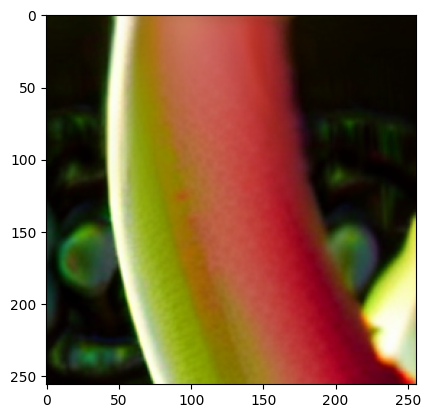

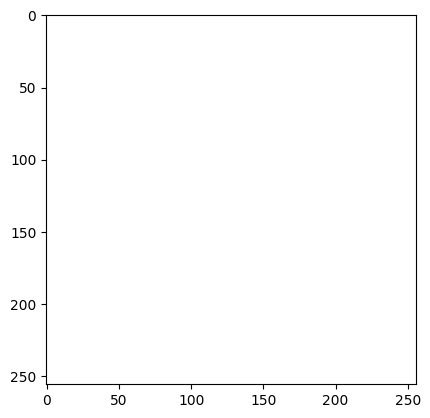

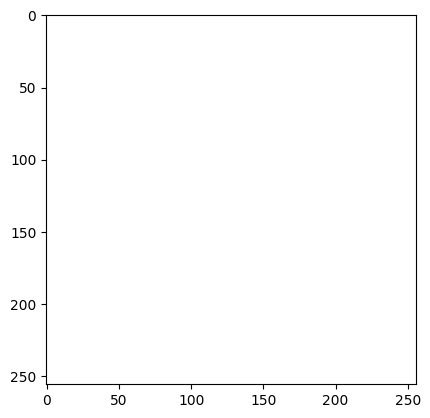

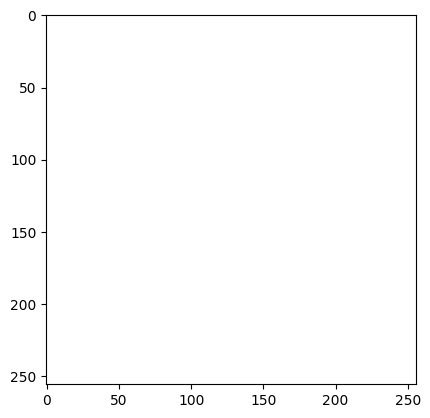

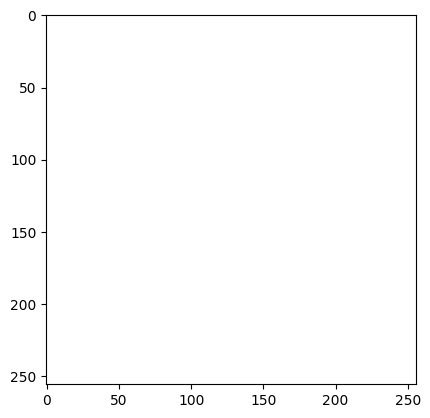

In [2]:
import sys, os
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')
import time

IMAGE_PATH = "../data/vggface_small_flat/n000454_008201.jpg"
#IMAGE_PATH = "../data/pubfig_small_flat/AdamSandler_38.jpg"

so = ort.SessionOptions()
so.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL  # optional, forces single-thread
so.intra_op_num_threads = 1
so.inter_op_num_threads = 1
# This flag prevents ORT from messing with thread affinity
so.add_session_config_entry("session.set_denormal_as_zero", "1")
so.add_session_config_entry("session.disable_prepacking", "1")

from insightface.app import FaceAnalysis
from PIL import Image
app = FaceAnalysis(name='antelopev2', root='./arc2face', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'], sess_options=so)
app.prepare(ctx_id=0, det_size=(640, 640))

sys.stderr = stderr

# read in the image
img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
print(img.shape)

# get the arcface embedding
faces = app.get(img)
faces = sorted(faces, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)
id_emb = torch.tensor(faces['embedding'], dtype=torch.float16)[None].cuda()
print("FaceAnalysis embedding has range", torch.min(id_emb), torch.max(id_emb))
id_emb = id_emb/torch.norm(id_emb, dim=1, keepdim=True)   # normalize embedding
print("FaceAnalysis embedding post-norm has range", torch.min(id_emb), torch.max(id_emb))
# project to the pipeline and ask for gradients

id_emb = project_face_embs(pipeline, id_emb).detach().clone()   # ensure no history
id_emb.requires_grad_(True)
print("Range of embeds:", torch.min(id_emb), torch.max(id_emb))

# UNCOMMENT IF WE DON'T CARE ABOUT GRADIENTS
# num_images=4
# start = time.perf_counter()
# images = pipeline(prompt_embeds=id_emb, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images, output_type="pt").images
# end = time.perf_counter()
# print(f"Generating {num_images} took {end-start} seconds")

NUM_ITERS = 5
optimizer = torch.optim.AdamW([id_emb], lr=0.001)

for _ in range(NUM_ITERS):
    images, pil_images = pipeline_forward_with_grad(
        pipeline,
        prompt_embeds=id_emb,
        num_inference_steps=50,
        guidance_scale=3.0,
        height=256,
        width=256,
    )
    
    plt.imshow(2.0*(pil_images-0.5))
    plt.show()

    optimizer.zero_grad()
    optimizer = torch.optim.AdamW([id_emb], lr=0.1)

    loss = torch.sum(images[0])
    loss.backward()

    old_id_emb = id_emb.clone()

    optimizer.step()
    old_id_emb[:, 4, :] = id_emb[:, 4, :]
    id_emb = old_id_emb.clone().detach()

In [ ]:
print(len(images))
# im0 = images[0].detach().cpu().float().numpy().transpose((1, 2, 0))
# plt.imshow(im0)
# plt.show()

optimizer.zero_grad()
optimizer = torch.optim.AdamW([id_emb], lr=0.001)

print("id emb is", id_emb)
loss = torch.sum(images[0])
loss.backward()
print("id_emb grad is", id_emb.grad)

def grad_hook(grad):
    return grad * mask

old_id_emb = id_emb.clone()

optimizer.step()
old_id_emb[:, 4, :] = id_emb[:, 4, :]
id_emb = old_id_emb.clone().detach()
print("id emb is", id_emb)